# Skorch Time Series Demo

Forecasting airline passenger counts with an LSTM wrapped in skorch's sklearn-compatible API.

We use the classic **AirPassengers** dataset (monthly international airline passengers, 1949-1960) and train an LSTM to predict the next month from a rolling window of past months.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping

torch.manual_seed(0)
np.random.seed(0)

## 1. Load the data

The AirPassengers series exhibits both trend and annual seasonality, which makes it a good benchmark for recurrent models.

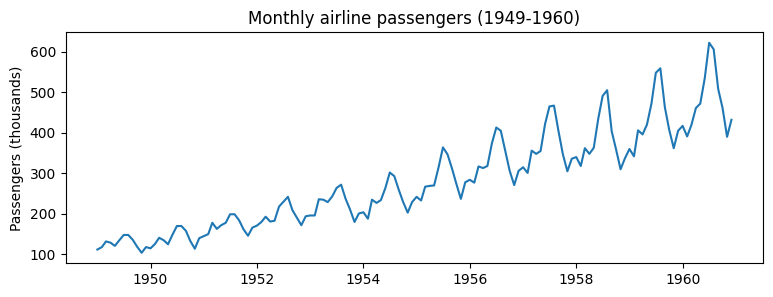

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")
series = df["Passengers"].astype("float32").values

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(df.index, series)
ax.set_title("Monthly airline passengers (1949-1960)")
ax.set_ylabel("Passengers (thousands)")
plt.show()

## 2. Build sliding-window supervised data

To turn the univariate series into an `(X, y)` regression problem we slide a window of length `lookback=12` (one year of history) across the series. `X` has shape `(n_samples, lookback, 1)`; `y` is the next month's value.

In [3]:
LOOKBACK = 12

scaler = StandardScaler()
scaled = scaler.fit_transform(series.reshape(-1, 1)).astype("float32").ravel()

def make_windows(values, lookback):
    X, y = [], []
    for i in range(len(values) - lookback):
        X.append(values[i : i + lookback])
        y.append(values[i + lookback])
    X = np.asarray(X, dtype="float32")[..., np.newaxis]
    y = np.asarray(y, dtype="float32").reshape(-1, 1)
    return X, y

X_all, y_all = make_windows(scaled, LOOKBACK)

# Chronological train/test split — never shuffle time series.
split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (105, 12, 1), y_train: (105, 1)
X_test:  (27, 12, 1), y_test:  (27, 1)


## 3. Define the LSTM module

A minimal PyTorch `nn.Module` with a single LSTM layer and a linear head. Skorch will handle the training loop.

In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

## 4. Wrap with skorch and fit

`NeuralNetRegressor` gives us `.fit`, `.predict`, and sklearn-style hyperparameter access (e.g. `module__hidden_size`) — handy for `GridSearchCV` later.

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

net = NeuralNetRegressor(
    module=LSTMRegressor,
    module__hidden_size=32,
    module__num_layers=1,
    max_epochs=200,
    lr=1e-2,
    optimizer=torch.optim.Adam,
    criterion=nn.MSELoss,
    batch_size=16,
    iterator_train__shuffle=True,
    callbacks=[EarlyStopping(patience=20)],
    device=device,
    verbose=0,
)

net.fit(X_train, y_train)
print(f"Trained for {len(net.history)} epochs on {device}.")

Trained for 96 epochs on cpu.


## 5. Evaluate and plot

In [6]:
def inverse(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).ravel()

pred_train = inverse(net.predict(X_train))
pred_test = inverse(net.predict(X_test))
true_train = inverse(y_train)
true_test = inverse(y_test)

rmse = float(np.sqrt(np.mean((pred_test - true_test) ** 2)))
mape = float(np.mean(np.abs((pred_test - true_test) / true_test)) * 100)
print(f"Test RMSE: {rmse:.2f} passengers")
print(f"Test MAPE: {mape:.2f}%")

Test RMSE: 46.36 passengers
Test MAPE: 6.99%


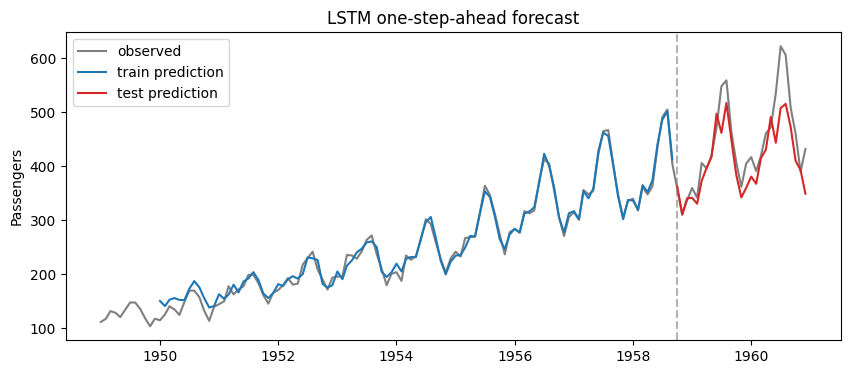

In [7]:
idx = df.index[LOOKBACK:]
train_idx = idx[:split]
test_idx = idx[split:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.index, series, label="observed", color="black", alpha=0.5)
ax.plot(train_idx, pred_train, label="train prediction", color="tab:blue")
ax.plot(test_idx, pred_test, label="test prediction", color="tab:red")
ax.axvline(test_idx[0], color="gray", linestyle="--", alpha=0.6)
ax.set_title("LSTM one-step-ahead forecast")
ax.set_ylabel("Passengers")
ax.legend()
plt.show()

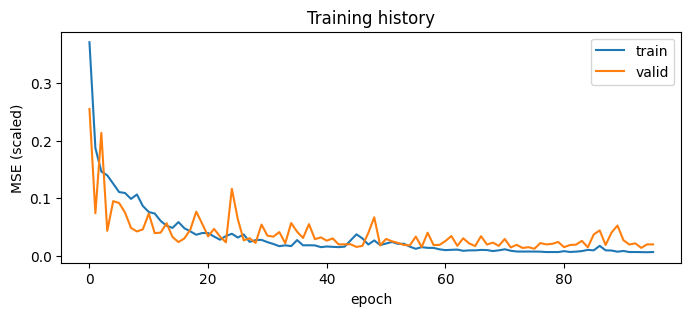

In [8]:
history = net.history
train_loss = history[:, "train_loss"]
valid_loss = history[:, "valid_loss"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_loss, label="train")
ax.plot(valid_loss, label="valid")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (scaled)")
ax.set_title("Training history")
ax.legend()
plt.show()

## 6. Multi-step rolling forecast

Skorch's `.predict` is one-step-ahead. To forecast further out we feed the model's own prediction back in and roll the window forward.

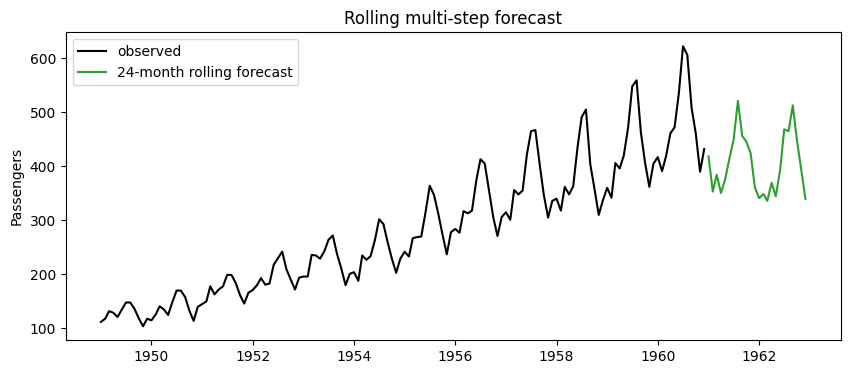

In [9]:
HORIZON = 24  # months

window = scaled[-LOOKBACK:].copy()
rolling = []
for _ in range(HORIZON):
    x = window.reshape(1, LOOKBACK, 1).astype("float32")
    y_hat = float(net.predict(x).ravel()[0])
    rolling.append(y_hat)
    window = np.append(window[1:], y_hat)

rolling = inverse(np.array(rolling))
future_idx = pd.date_range(df.index[-1] + pd.offsets.MonthBegin(), periods=HORIZON, freq="MS")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.index, series, label="observed", color="black")
ax.plot(future_idx, rolling, label=f"{HORIZON}-month rolling forecast", color="tab:green")
ax.set_title("Rolling multi-step forecast")
ax.set_ylabel("Passengers")
ax.legend()
plt.show()

## 7. Compare architectures & optimizers with skore

[`skore`](https://skore.probabl.ai/) wraps fitted sklearn-compatible estimators in `EstimatorReport`s that share the same held-out test set, then `ComparisonReport` lines up their metrics side by side. Since skorch's `NeuralNetRegressor` is sklearn-compatible, we can drop our LSTM/MLP variants straight in.

We'll sweep four axes:
- **architecture**: LSTM vs a simple MLP on the flattened window
- **hidden size**: 16 vs 64
- **optimizer**: SGD (with momentum) vs Adam
- **learning rate**: 1e-3 vs 1e-2

In [10]:
from sklearn.base import BaseEstimator, RegressorMixin
from skore import EstimatorReport, ComparisonReport


class SkorchRegressor(BaseEstimator, RegressorMixin):
    """Sklearn-facing wrapper around a skorch net.

    Exposes only fit/predict/score. skorch's own predict_proba would confuse
    skore's response-method probe into treating the estimator as a classifier,
    so we don't forward it.
    """
    def __init__(self, net):
        self.net = net

    def fit(self, X, y):
        self.net.fit(X, y)
        return self

    def predict(self, X):
        return self.net.predict(X).ravel()

    @property
    def history(self):
        return self.net.history


class MLPRegressorModule(nn.Module):
    """Baseline: flatten the window and use a small feed-forward net."""
    def __init__(self, lookback=LOOKBACK, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(lookback, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.net(x)


In [11]:
def build_net(module_cls, *, hidden_size, optimizer, lr, module_kwargs=None):
    module_kwargs = module_kwargs or {}
    opt_kwargs = {"optimizer__momentum": 0.9} if optimizer is torch.optim.SGD else {}
    return NeuralNetRegressor(
        module=module_cls,
        module__hidden_size=hidden_size,
        **{f"module__{k}": v for k, v in module_kwargs.items()},
        max_epochs=200,
        lr=lr,
        optimizer=optimizer,
        **opt_kwargs,
        criterion=nn.MSELoss,
        batch_size=16,
        iterator_train__shuffle=True,
        callbacks=[EarlyStopping(patience=20)],
        device=device,
        verbose=0,
    )


# Curated sweep — not a full grid, just the contrasts we care about.
configs = {
    "LSTM-h32-adam-1e-2":  dict(module_cls=LSTMRegressor, hidden_size=32, optimizer=torch.optim.Adam, lr=1e-2),
    "LSTM-h16-adam-1e-3":  dict(module_cls=LSTMRegressor, hidden_size=16, optimizer=torch.optim.Adam, lr=1e-3),
    "LSTM-h64-adam-1e-2":  dict(module_cls=LSTMRegressor, hidden_size=64, optimizer=torch.optim.Adam, lr=1e-2),
    "LSTM-h32-sgd-1e-2":   dict(module_cls=LSTMRegressor, hidden_size=32, optimizer=torch.optim.SGD,  lr=1e-2),
    "LSTM-h32-sgd-1e-3":   dict(module_cls=LSTMRegressor, hidden_size=32, optimizer=torch.optim.SGD,  lr=1e-3),
    "MLP-h32-adam-1e-2":   dict(module_cls=MLPRegressorModule, hidden_size=32, optimizer=torch.optim.Adam, lr=1e-2),
    "MLP-h64-adam-1e-3":   dict(module_cls=MLPRegressorModule, hidden_size=64, optimizer=torch.optim.Adam, lr=1e-3),
    "MLP-h32-sgd-1e-2":    dict(module_cls=MLPRegressorModule, hidden_size=32, optimizer=torch.optim.SGD,  lr=1e-2),
}

# skore compares 1D y with 1D predictions.
y_train_1d = y_train.ravel()
y_test_1d = y_test.ravel()


In [12]:
reports = {}
for name, cfg in configs.items():
    torch.manual_seed(0)
    net_i = build_net(**cfg)
    net_i.fit(X_train, y_train)  # skorch still wants 2D y for training
    wrapped = SkorchRegressor(net_i)
    reports[name] = EstimatorReport(
        wrapped,
        fit=False,  # already fit
        X_train=X_train, y_train=y_train_1d,
        X_test=X_test,   y_test=y_test_1d,
    )
    print(f"{name:24s}  epochs={len(net_i.history):3d}")


LSTM-h32-adam-1e-2        epochs= 96
LSTM-h16-adam-1e-3        epochs= 41
LSTM-h64-adam-1e-2        epochs=116
LSTM-h32-sgd-1e-2         epochs= 44
LSTM-h32-sgd-1e-3         epochs=155
MLP-h32-adam-1e-2         epochs= 40
MLP-h64-adam-1e-3         epochs= 97
MLP-h32-sgd-1e-2          epochs= 92


### Side-by-side metrics

`ComparisonReport.metrics.report_metrics()` computes test-set metrics (R², RMSE, MAE, fit/predict time) for every model and returns a `DataFrame`.

In [13]:
comparison = ComparisonReport(reports)
summary = comparison.metrics.summarize().frame()
summary

Output()

Estimator,LSTM-h32-adam-1e-2,LSTM-h16-adam-1e-3,LSTM-h64-adam-1e-2,LSTM-h32-sgd-1e-2,LSTM-h32-sgd-1e-3,MLP-h32-adam-1e-2,MLP-h64-adam-1e-3,MLP-h32-sgd-1e-2
Metric,,,,,,,,
R²,0.661672,-0.108971,0.775118,0.346051,0.267704,0.784533,0.895489,0.701681
RMSE,0.387765,0.702038,0.316139,0.539104,0.570484,0.309450,0.215517,0.364117
Fit time (s),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Predict time (s),0.002220,0.002502,0.002633,0.001535,0.002650,0.000895,0.000696,0.000761


In [14]:
# Flatten skore's MultiIndex columns for easy ranking.
flat = summary.copy()
if hasattr(flat.columns, 'get_level_values'):
    flat.columns = flat.columns.get_level_values(-1)
flat

Estimator,LSTM-h32-adam-1e-2,LSTM-h16-adam-1e-3,LSTM-h64-adam-1e-2,LSTM-h32-sgd-1e-2,LSTM-h32-sgd-1e-3,MLP-h32-adam-1e-2,MLP-h64-adam-1e-3,MLP-h32-sgd-1e-2
Metric,,,,,,,,
R²,0.661672,-0.108971,0.775118,0.346051,0.267704,0.784533,0.895489,0.701681
RMSE,0.387765,0.702038,0.316139,0.539104,0.570484,0.309450,0.215517,0.364117
Fit time (s),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Predict time (s),0.002220,0.002502,0.002633,0.001535,0.002650,0.000895,0.000696,0.000761


Output()

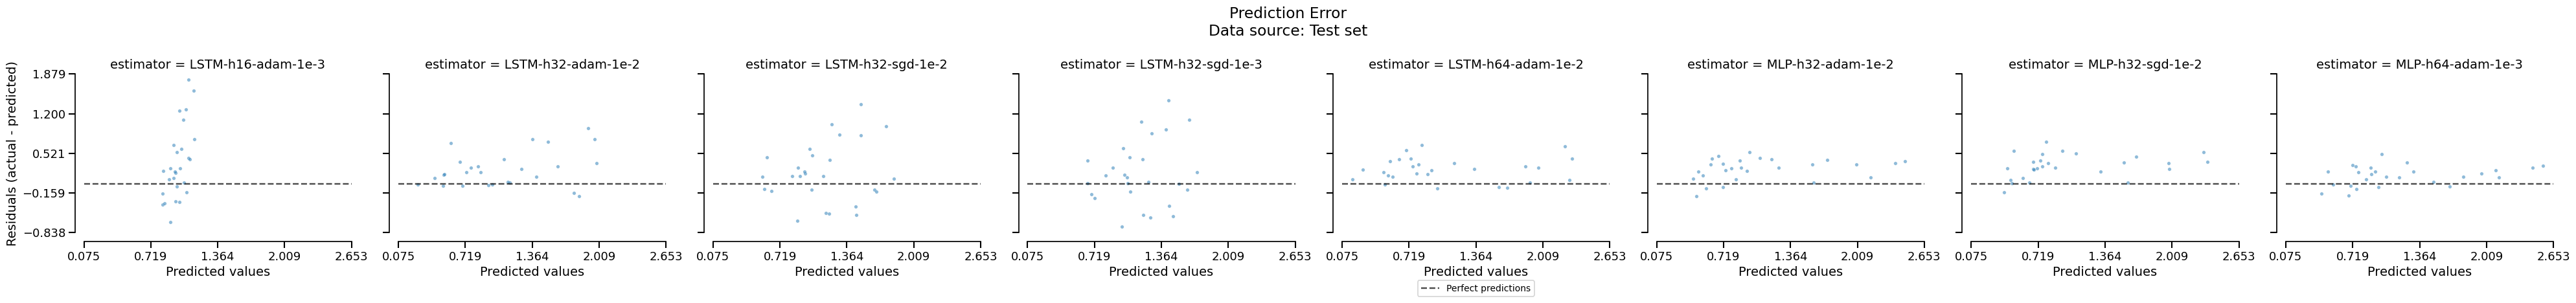

In [17]:
# Prediction-error plot (predicted vs actual) for every model.
comparison.metrics.prediction_error().plot()

### Reading the comparison

- **Adam vs SGD**: on this tiny dataset Adam converges in tens of epochs; SGD at the same lr often stalls — early stopping cuts it off before it catches up.
- **LSTM vs MLP**: the MLP on a flattened 12-month window is a strong baseline here because the seasonality is exactly one window long. The LSTM's advantage shows up more on longer / irregular series.
- **Learning rate**: 1e-2 is aggressive but works with Adam + early stopping; 1e-3 is safer but may underfit within the epoch budget.

Swap in new configs and re-run — skore keeps the comparison table stable as the sweep grows.